In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
train_data = "Malaria_dataset/Malaria_Dataset/train"
valid_data = "Malaria_dataset/Malaria_Dataset/valid"
test_data  = "Malaria_dataset/Malaria_Dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_data,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_data,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 13152 images belonging to 2 classes.
Found 1253 images belonging to 2 classes.
Found 626 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')   # Binary classification
])

C:\Users\Gopika\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15
)
predictions = model.predict(test_generator)
pred_classes = (predictions > 0.5).astype("int32")

print(classification_report(test_generator.classes, pred_classes))

C:\Users\Gopika\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.5407 - loss: 0.6877 - val_accuracy: 0.6345 - val_loss: 0.6439
Epoch 2/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 404s 983ms/step - accuracy: 0.6183 - loss: 0.6468 - val_accuracy: 0.7326 - val_loss: 0.5609
Epoch 3/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 427s 1s/step - accuracy: 0.7176 - loss: 0.5533 - val_accuracy: 0.8045 - val_loss: 0.4506
Epoch 4/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.8143 - loss: 0.4293 - val_accuracy: 0.8667 - val_loss: 0.3111
Epoch 5/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.8848 - loss: 0.3097 - val_accuracy: 0.9130 - val_loss: 0.2328
Epoch 6/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 2592s 6s/step - accuracy: 0.9245 - loss: 0.2274 - val_accuracy: 0.9234 - val_loss: 0.2139
Epoch 7/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 392s 953ms/step - accuracy: 0.9278 - loss: 0.2038 - val_accuracy: 0.9242 - val_loss: 0.2099
Epoch 8/15
411/411 ━━━━━━━━━━━━━━━━━━━━ 403s 980ms/step - accuracy: 0.9471 - loss: 0.1648 

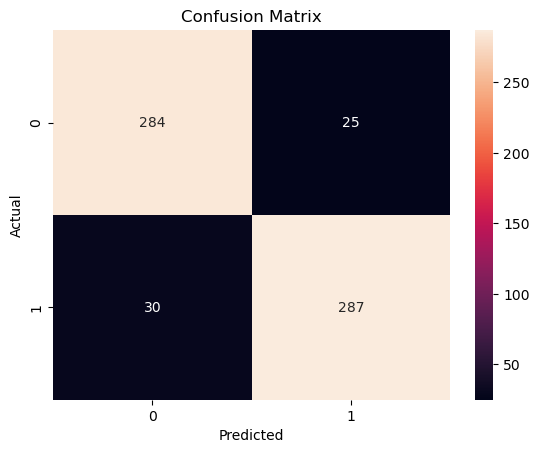

In [18]:
cm = confusion_matrix(test_generator.classes, pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       309
           1       0.92      0.91      0.91       317

    accuracy                           0.91       626
   macro avg       0.91      0.91      0.91       626
weighted avg       0.91      0.91      0.91       626



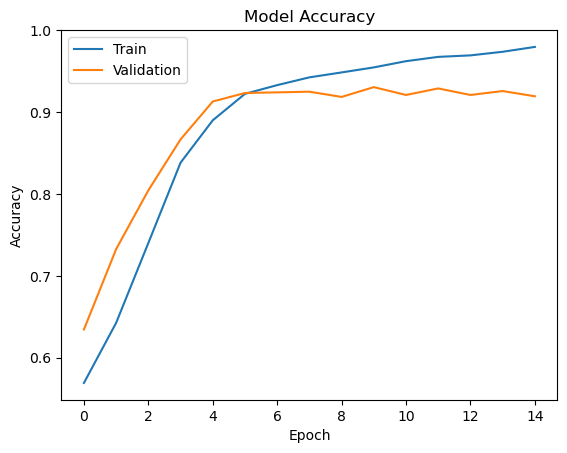

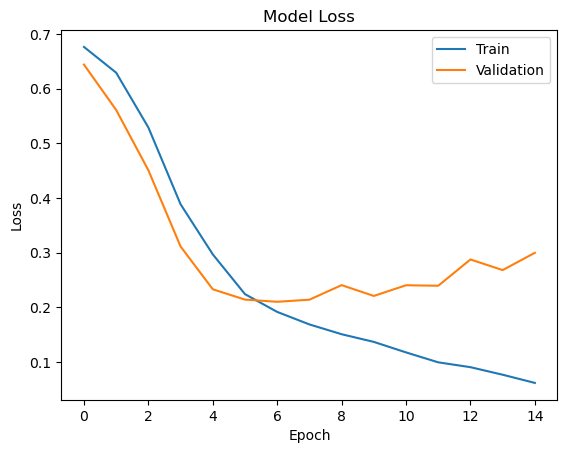

In [ ]:
predictions = model.predict(test_generator)
pred_classes = (predictions > 0.5).astype("int32")

print(classification_report(test_generator.classes, pred_classes))
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show() 

In [ ]:
model.save("model/malaria_model_cnn.h5")